# Clasificador de rango etario 

### Modificación respecto al estudio anterior: `Categorías balanceadas`

Clasificación multiclase en 5 clases a partir de fotos de rostros. Armamos el mismo modelo en PyTorch y en TensorFlow/Keras para poder comparar los dos frameworks.

Rangos que usamos:

| Clase | Rango | Etiqueta |
|---|---|---|
| 0 | 0-12 | niño |
| 1 | 13-19 | adolescente |
| 2 | 20-35 | joven |
| 3 | 36-59 | adulto |
| 4 | 60+ | viejo |


# Desarrollo

In [1]:
# --- Configuración general ---
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"     # carpeta única con todas las imágenes (sin subcarpetas por clase)
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [2]:
# --- Definición de los rangos etarios ---
CLASS_NAMES = ["nino", "adolescente", "joven", "adulto", "viejo"]

def age_to_bucket(age: int) -> int:
    """Convierte una edad entera al índice de clase (0-4) según los rangos definidos."""
    if age <= 12:
        return 0  # nino
    elif age <= 19:
        return 1  # adolescente
    elif age <= 35:
        return 2  # joven
    elif age <= 59:
        return 3  # adulto
    else:
        return 4  # viejo

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

In [3]:
# --- Construcción del dataframe desde la carpeta única UTKFace ---
# La etiqueta se calcula parseando la edad del NOMBRE DE ARCHIVO (no hay subcarpetas por clase).
# Para balancear sin duplicar imágenes en disco: se muestrea aleatoriamente el mínimo común (cap)
# de imágenes por clase, con semilla fija para reproducibilidad.
all_fps = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
if len(all_fps) == 0:
    raise FileNotFoundError(
        f"No hay imágenes en '{DATA_DIR}'. Revisa que la carpeta UTKFace exista con los .jpg "
        "directamente adentro (ver celda de descarga del dataset)."
    )

records_by_class = {i: [] for i in range(len(CLASS_NAMES))}
skipped = 0
for fp in all_fps:
    age = parse_age_from_filename(fp)
    if age is None:
        skipped += 1
        continue
    records_by_class[age_to_bucket(age)].append(fp)

print(f"Imágenes totales encontradas: {len(all_fps)}  |  Descartadas (nombre no calza el formato): {skipped}")
print("Disponibles por clase (antes de balancear):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {len(records_by_class[i])}")

cap = min(len(fps) for fps in records_by_class.values())
print(f"\nCap por clase (mínimo común): {cap}")

rng = np.random.RandomState(SEED)
records = []
for label_idx, fps in records_by_class.items():
    sampled = rng.choice(fps, size=cap, replace=False)
    for fp in sampled:
        records.append({"filepath": fp, "label": label_idx})

df = pd.DataFrame(records, columns=["filepath", "label"])
print(f"\nImágenes usadas para entrenar (balanceado): {len(df)}")
print("Por clase:")
print(df["label"].value_counts().sort_index().rename(index=lambda i: CLASS_NAMES[i]))
df.head()

Imágenes totales encontradas: 23708  |  Descartadas (nombre no calza el formato): 3
Disponibles por clase (antes de balancear):
  nino: 3413
  adolescente: 1180
  joven: 10514
  adulto: 5910
  viejo: 2688

Cap por clase (mínimo común): 1180

Imágenes usadas para entrenar (balanceado): 5900
Por clase:
label
nino           1180
adolescente    1180
joven          1180
adulto         1180
viejo          1180
Name: count, dtype: int64


,filepath,label
0,./UTKFace_data/UTKFace\3_0_0_20170109192415151...,0
1,./UTKFace_data/UTKFace\2_1_2_20161219160232453...,0
2,./UTKFace_data/UTKFace\11_0_0_2017011022474203...,0
3,./UTKFace_data/UTKFace\1_0_2_20161219203236876...,0
4,./UTKFace_data/UTKFace\6_1_2_20161219201340515...,0


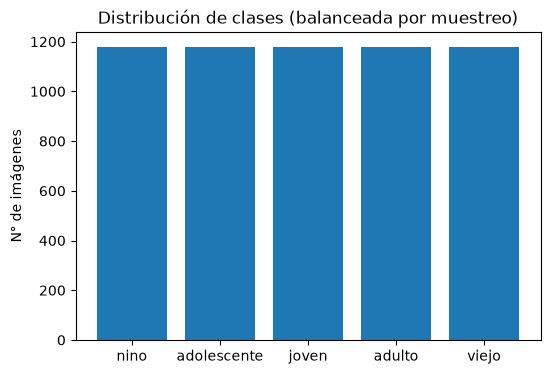

label
nino           1180
adolescente    1180
joven          1180
adulto         1180
viejo          1180
Name: count, dtype: int64


In [4]:
# --- Distribución de clases ---
counts = df["label"].value_counts().reindex(range(len(CLASS_NAMES)), fill_value=0)
plt.figure(figsize=(6, 4))
plt.bar(CLASS_NAMES, counts.values)
plt.title("Distribución de clases (balanceada por muestreo)")
plt.ylabel("N° de imágenes")
plt.show()

print(counts.rename(index=lambda i: CLASS_NAMES[i]))
# Balanceado por muestreo (cap = mínimo común entre clases) -> barras del mismo alto.

In [5]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 4130  |  Val: 885  |  Test: 885


## Parte A: PyTorch


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import time
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [7]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [8]:
# --- Entrenamiento (PyTorch) ---
ti1=time.time()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")


tf1=time.time()
t_total = tf1 - ti1
print(f"\nTiempo total de entrenamiento (PyTorch): {t_total:.2f} segundos")

Epoch 1/10 | train_loss=1.3987 train_acc=0.3751 | val_loss=1.1493 val_acc=0.5085
Epoch 2/10 | train_loss=1.1165 train_acc=0.5215 | val_loss=1.0499 val_acc=0.5740
Epoch 3/10 | train_loss=1.0297 train_acc=0.5644 | val_loss=0.9959 val_acc=0.5763
Epoch 4/10 | train_loss=0.9427 train_acc=0.5973 | val_loss=0.9692 val_acc=0.5977
Epoch 5/10 | train_loss=0.8893 train_acc=0.6203 | val_loss=0.8989 val_acc=0.6113
Epoch 6/10 | train_loss=0.8133 train_acc=0.6593 | val_loss=0.9224 val_acc=0.6068
Epoch 7/10 | train_loss=0.7557 train_acc=0.6823 | val_loss=0.9120 val_acc=0.6282
Epoch 8/10 | train_loss=0.6866 train_acc=0.7015 | val_loss=0.8869 val_acc=0.6362
Epoch 9/10 | train_loss=0.6267 train_acc=0.7366 | val_loss=0.9379 val_acc=0.6271
Epoch 10/10 | train_loss=0.5750 train_acc=0.7591 | val_loss=0.9069 val_acc=0.6418

Tiempo total de entrenamiento (PyTorch): 134.10 segundos


              precision    recall  f1-score   support

        nino       0.90      0.82      0.86       177
 adolescente       0.57      0.77      0.66       177
       joven       0.59      0.50      0.54       177
      adulto       0.56      0.47      0.51       177
       viejo       0.74      0.79      0.77       177

    accuracy                           0.67       885
   macro avg       0.67      0.67      0.67       885
weighted avg       0.67      0.67      0.67       885



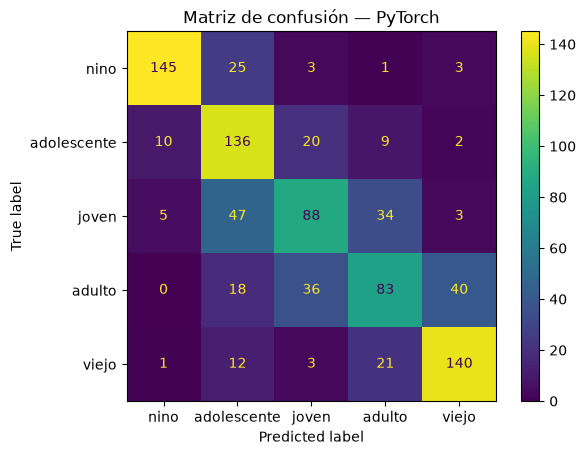

In [9]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — PyTorch")
plt.show()

### Curva ROC — PyTorch

Curva ROC multiclase (One-vs-Rest): cada clase se compara contra el resto. El AUC resume la curva en un número: cercano a **1.0** = excelente separación, **0.5** = equivale al azar. La curva punteada negra es el **micro-promedio** (todas las clases juntas).

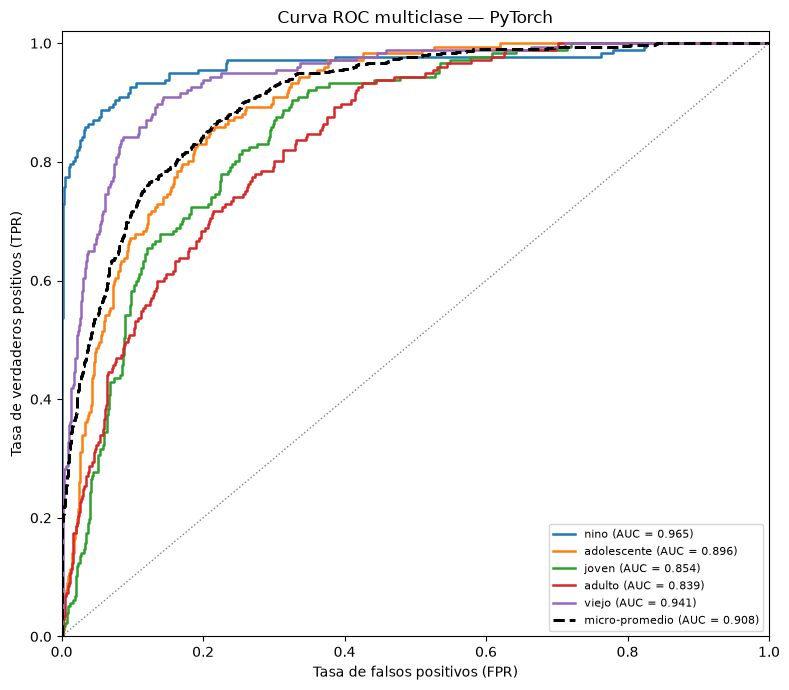

In [10]:
# --- Curva ROC (PyTorch) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Recolectamos las probabilidades (softmax) del modelo sobre el set de test.
model_pt.eval()
probs_pt, y_roc_pt = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        p = F.softmax(model_pt(imgs), dim=1)
        probs_pt.extend(p.cpu().numpy())
        y_roc_pt.extend(labels.numpy())
probs_pt = np.array(probs_pt)
y_roc_pt = np.array(y_roc_pt)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_pt, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_pt[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

# Micro-promedio: junta todas las clases en una sola curva global.
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_pt.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — PyTorch")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Parte B: TensorFlow / Keras


In [11]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [12]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,645 (2.09 MB)

 Trainable params: 548,645 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# --- Entrenamiento (Keras) ---
ti2=time.time()
EPOCHS_TF = 10
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)

tf2=time.time()
t_total = tf2 - ti2
print(f"\nTiempo total de entrenamiento (Keras): {t_total:.2f} segundos")

Epoch 1/10


c:\Users\fsali\Documents\GitHub\frameworks-ia-2026_udd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.3324 - loss: 1.4970 - val_accuracy: 0.4599 - val_loss: 1.2261
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5002 - loss: 1.1729 - val_accuracy: 0.5096 - val_loss: 1.1287
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5472 - loss: 1.0904 - val_accuracy: 0.5819 - val_loss: 0.9824
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5906 - loss: 0.9822 - val_accuracy: 0.5932 - val_loss: 0.9757
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6153 - loss: 0.9148 - val_accuracy: 0.6090 - val_loss: 0.9071
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6312 - loss: 0.8838 - val_accuracy: 0.6169 - val_loss: 0.8865
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6550 - loss: 0.8230 - val_accuracy: 0.6147 - val_loss: 0.8999
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6831 - loss: 0.7611 - val_accuracy: 0.632

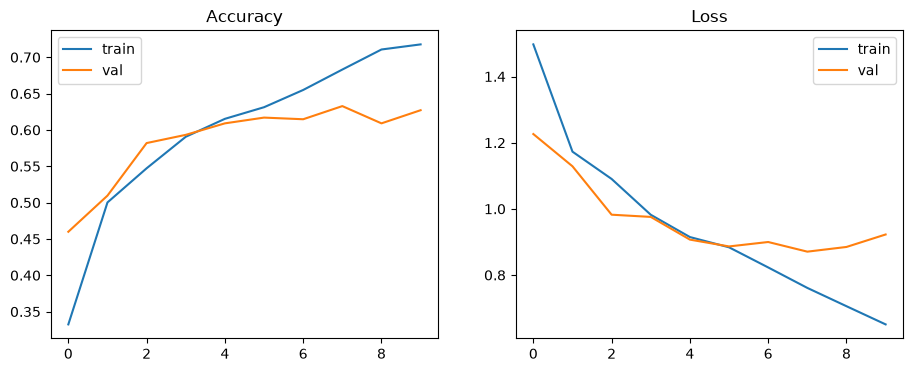

In [14]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

        nino       0.81      0.86      0.84       177
 adolescente       0.58      0.59      0.58       177
       joven       0.50      0.66      0.57       177
      adulto       0.70      0.28      0.40       177
       viejo       0.67      0.80      0.73       177

    accuracy                           0.64       885
   macro avg       0.65      0.64      0.62       885
weighted avg       0.65      0.64      0.62       885



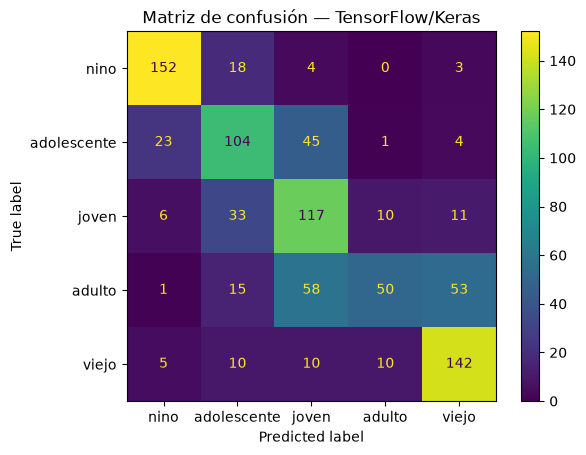

In [15]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — TensorFlow/Keras")
plt.show()

### Curva ROC — TensorFlow/Keras

Misma lectura que la ROC de PyTorch, ahora para el modelo de Keras. Sirve para comparar la capacidad de separación de ambos frameworks clase por clase.

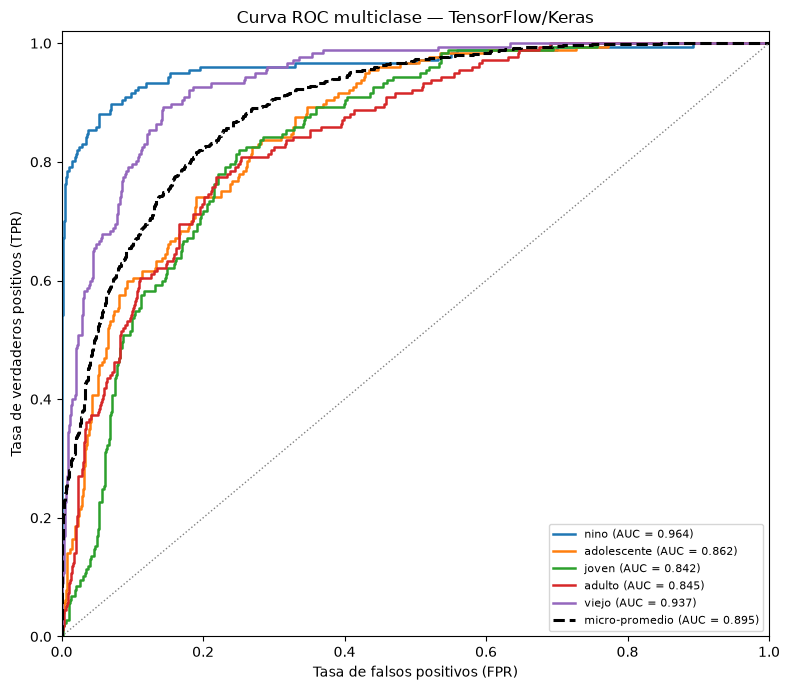

In [16]:
# --- Curva ROC (Keras) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# El modelo de Keras ya entrega softmax en su capa final.
probs_tf, y_roc_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    probs_tf.extend(preds)
    y_roc_tf.extend(labels.numpy())
probs_tf = np.array(probs_tf)
y_roc_tf = np.array(y_roc_tf)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_tf, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_tf[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_tf.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — TensorFlow/Keras")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Comparación final

A partir de la curva ROC, se observa que el modelo discrimina con gran éxito las edades extremas (nino y viejo), pero presenta dificultades para clasificar las etapas intermedias de desarrollo: joven (AUC = 0.842), adulto (0.845) y adolescente (0.862). En estas clases existe una mayor confusión visual, lo que provoca que la tasa de falsos positivos crezca rápidamente al intentar maximizar los aciertos.  
**Debido a esta dificultad técnica para separar categorías con características físicas tan similares, en el siguiente notebook haremos la prueba variando la cantidad de clases para buscar un mejor rendimiento.**

## Prueba

Test hecho con fotos propias y algunas fotos sacadas del dataset. Estas están en la carpeta fotos_prueba.


Fotos encontradas: 16


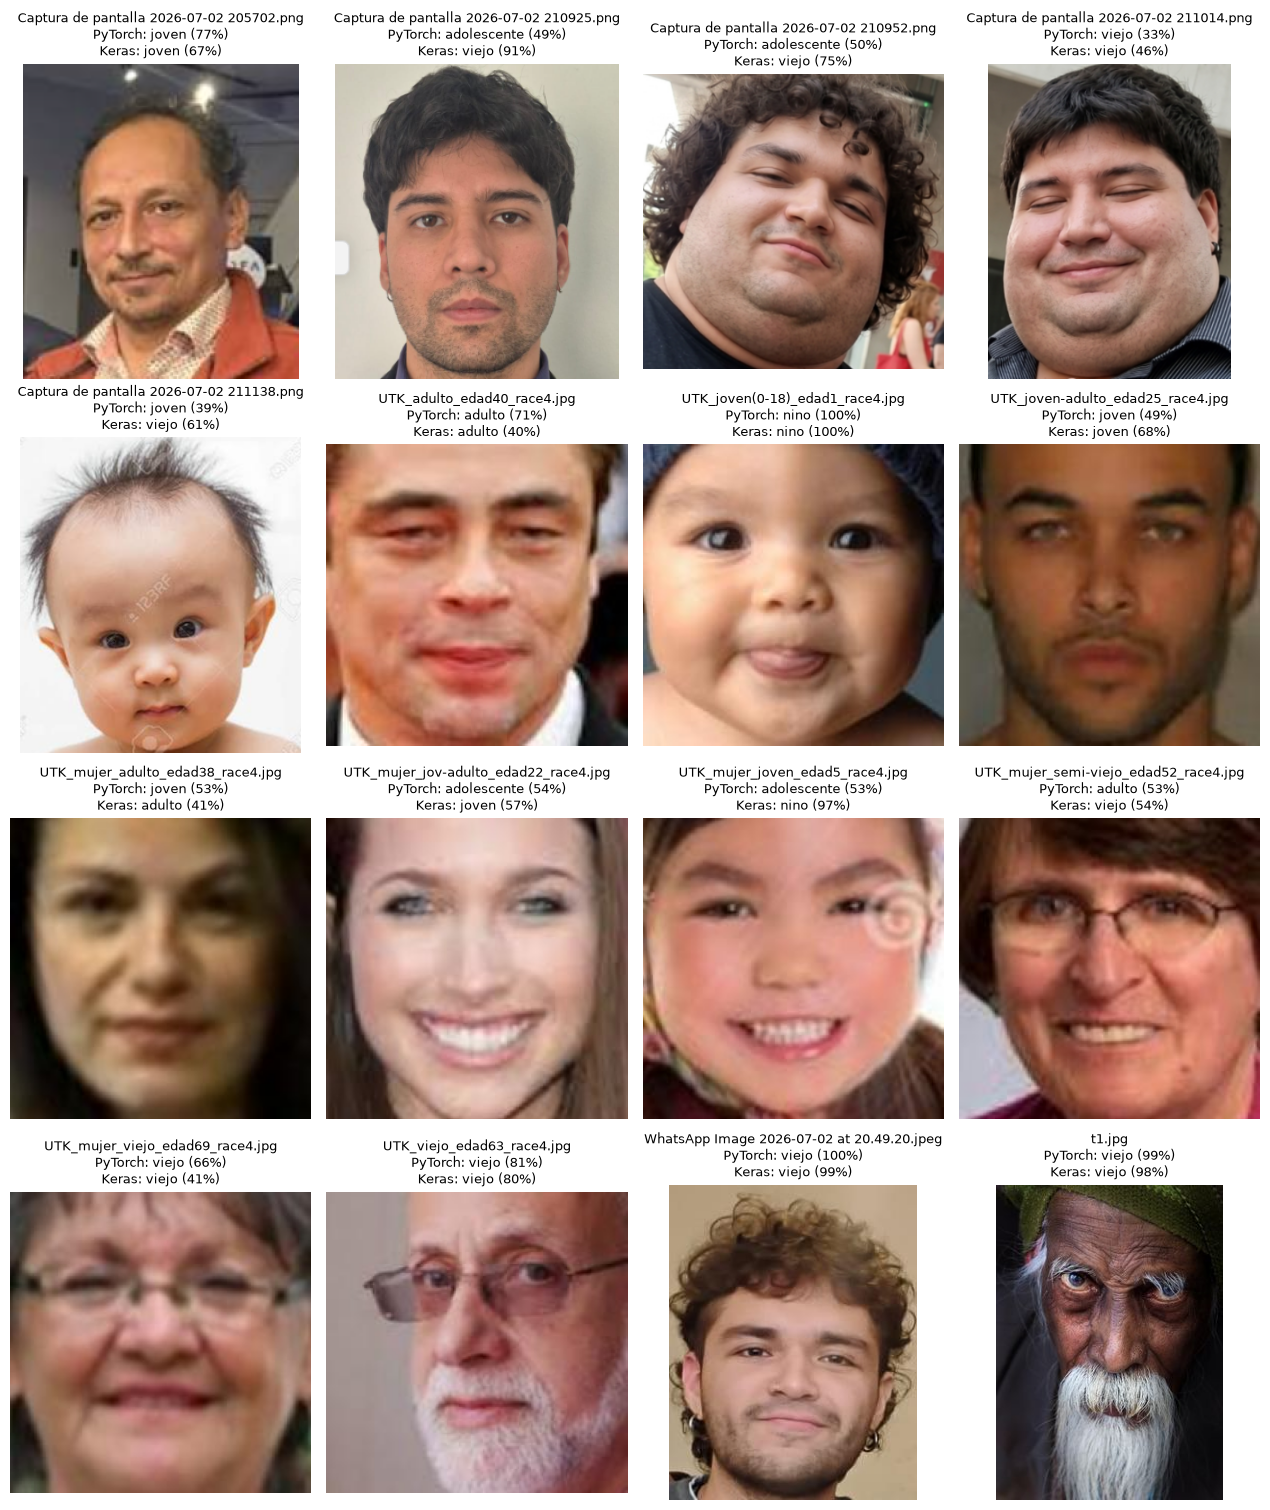

In [17]:
# --- Prueba con imágenes propias ---
# 1) Deja tus fotos (una cara por imagen) en la carpeta FOTOS_PRUEBA.
# 2) Ejecuta esta celda DESPUÉS de haber entrenado los modelos más arriba.
import glob
from PIL import Image

FOTOS_PRUEBA = "./fotos_prueba"   # <-- carpeta con tus imágenes de prueba

exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
rutas = []
for e in exts:
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e))
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e.upper()))
rutas = sorted(set(rutas))

if len(rutas) == 0:
    raise FileNotFoundError(
        f"No encontré imágenes en '{FOTOS_PRUEBA}'. Crea la carpeta y deja adentro "
        "algunas fotos (jpg o png), con una cara por imagen."
    )
print(f"Fotos encontradas: {len(rutas)}")

tiene_pt = "model_pt" in globals()   # modelo PyTorch entrenado
tiene_tf = "model_tf" in globals()   # modelo Keras entrenado

def predecir_pytorch(img_pil):
    model_pt.eval()
    x = transform(img_pil).unsqueeze(0).to(device)   # mismo preprocesamiento del entrenamiento
    with torch.no_grad():
        probs = torch.softmax(model_pt(x), dim=1)[0].cpu().numpy()
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx])

def predecir_keras(img_pil):
    arr = np.asarray(img_pil.resize((IMG_SIZE, IMG_SIZE)), dtype="float32") / 255.0
    probs = model_tf.predict(arr[None, ...], verbose=0)[0]
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx])

# Muestra las fotos en una grilla con la predicción de cada modelo
n = len(rutas)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.8))
axes = np.array(axes).reshape(-1)

for ax, ruta in zip(axes, rutas):
    img = Image.open(ruta).convert("RGB")
    lineas = [os.path.basename(ruta)]
    if tiene_pt:
        lab, p = predecir_pytorch(img)
        lineas.append(f"PyTorch: {lab} ({p*100:.0f}%)")
    if tiene_tf:
        lab, p = predecir_keras(img)
        lineas.append(f"Keras: {lab} ({p*100:.0f}%)")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("\n".join(lineas), fontsize=9)

for ax in axes[n:]:   # apaga los recuadros que sobran en la grilla
    ax.axis("off")

plt.tight_layout()
plt.show()
